
# Giải thích `Core/Octree.hpp` của LIMOncello

Notebook này giải thích riêng file `Octree.hpp` dùng để làm **global map backend** trong LIMOncello.

Mục tiêu của file này là:

1. lưu map dưới dạng **i-Octree tăng dần theo thời gian**,
2. hỗ trợ **chèn điểm mới** sau mỗi frame LiDAR,
3. hỗ trợ **tìm lân cận** rất nhanh bằng `knn(...)` và `radiusSearch(...)`,
4. cung cấp đúng các láng giềng mà `State::update()` cần để **fit local plane** và tạo residual point-to-plane.

Notebook bám theo đúng implementation hiện tại của `include/Core/Octree.hpp` trong repo LIMOncello, rồi nối nó với:

- phần **i-Octree backend** ở mục III-E của paper LIMOncello,
- và cách `State::update()` gọi `map.knn(...)` trước khi `estimate_plane(...)`.

Cách đọc nên giữ trong đầu một câu rất ngắn:

> `Octree.hpp` không làm Kalman filter. Nó chỉ làm một việc cực quan trọng: **trả về các điểm hàng xóm đủ nhanh để backend có thể dựng mặt phẳng và cập nhật pose theo thời gian thực**.



## 0. Đoạn code lõi cần nhớ

Dưới đây là **bản rút gọn** của file, chỉ giữ lại những phần quyết định hành vi của cây:

```cpp
namespace charlie {

using Point  = Eigen::Vector3f;
using Points = std::vector<Point>;

struct Heap {
  struct DistancePoint {
    float dist;
    Point point;
  };
  size_t capacity;
  size_t count;
  std::vector<DistancePoint> data;

  bool full() const { return count == capacity; }
  float worstDist() {
    return full() ? data[count-1].dist : std::numeric_limits<float>::max();
  }

  void addPoint(const Point& p, float dist) {
    if (full() and dist >= data[count-1].dist) return;
    if (count < capacity) ++count;
    int i = static_cast<int>(count) - 1;
    while (i > 0 && data[i-1].dist > dist) {
      data[i] = data[i-1];
      --i;
    }
    data[i].dist  = dist;
    data[i].point = p;
  }
};

struct Octant {
  Point centroid;   // center of the octant
  float extent;     // half of side-length
  Points points;    // only leaves keep points
  Octant **child;   // up to 8 children
};

struct Octree {
  Octant *root_;
  size_t num_points_;
  size_t bucket_size_;
  float  min_extent_;
  bool   downsample_;

  size_t ordered_indices[8][7] = {
    {1,2,4,3,5,6,7}, {0,3,5,2,4,7,6},
    {0,3,6,1,4,7,5}, {1,2,7,0,5,6,4},
    {0,5,6,1,2,7,3}, {1,4,7,0,3,6,2},
    {2,4,7,0,3,5,1}, {3,5,6,1,2,4,0}
  };

  inline size_t mortonCode(const Point& p, const Point& centroid) {
    size_t out(0);
    if (p.x() > centroid.x()) out |= 1;
    if (p.y() > centroid.y()) out |= 2;
    if (p.z() > centroid.z()) out |= 4;
    return out;
  }

  Octant* createOctant(const Point& centroid, float maxextent, const Points& points);
  template <typename ContainerT> void update(ContainerT& pts);
  void updateOctant(Octant*& octant, const Points& points);

  bool overlaps(const Octant* octant, const Point& query, const float& sqr_radius);

  template <typename PointT>
  void knn(const PointT& query, int k,
           std::vector<PointT>& neighbors,
           std::vector<float>& distances);

  bool knn(const Octant* octant, Point& query, Heap& heap);
};

} // namespace charlie
```

Toàn bộ file dài hơn khá nhiều, nhưng nếu hiểu được **6 mảnh** này thì bạn đã nắm gần hết ý tưởng:

- `Heap`
- `Octant`
- `mortonCode`
- `createOctant`
- `update / updateOctant`
- `overlaps / knn / radiusSearch`



## 1. File này đứng ở đâu trong pipeline của LIMOncello?

Trong paper, pipeline của LIMOncello là:

1. IMU propagation,
2. motion compensation cho point cloud,
3. downsample,
4. đăng ký point cloud hiện tại với **global map**,
5. dùng các correspondences đó để tạo residual và chạy **iterated update**.

Phần map backend ở bước 4 chính là **i-Octree**. Paper nói rõ backend map này được giữ dưới dạng incremental i-Octree, và mỗi điểm downsampled sẽ dùng **k-NN search** trong cây để fit một local plane trước khi xây point-to-plane residual. Phần mô tả đó nằm ở mục III-D và III-E của paper. *(nguồn: LIMOncello paper, mục III-E)*

Đúng với điều đó, trong `State::update()` ta thấy chuỗi:

```cpp
map.knn(query_global_point, k, neighbors, pointSearchSqDis);
estimate_plane(p_abcd, neighbors, plane_threshold);
z(i) = -dist2plane(plane, transformed_point);
```

Nói cách khác:

- `Octree.hpp` trả về các điểm hàng xóm trong map,
- `Plane.hpp` biến các hàng xóm đó thành một mặt phẳng cục bộ,
- `State.hpp` dùng mặt phẳng đó để tạo residual cho IESEKF. *(nguồn: State.hpp của LIMOncello)*



## 2. Ba cấu trúc dữ liệu bạn phải hiểu trước

### `Point` và `Points`

```cpp
using Point  = Eigen::Vector3f;
using Points = std::vector<Point>;
```

Map trong cây lưu thẳng các điểm 3D kiểu `float`. Không có normal, không có covariance, không có voxel feature riêng. Chỉ là các điểm.

### `Octant`

Một octant là **một ô lập phương trục song song** trong không gian, được mô tả bởi:

- `centroid`: tâm của ô,
- `extent`: **nửa cạnh** của ô,
- `points`: danh sách điểm nếu node là lá,
- `child[8]`: tối đa 8 con nếu node là node trong.

Điểm rất dễ nhầm:

\[
\text{side length} = 2 \cdot \text{extent}.
\]

Tức là `extent` **không phải** là cạnh của ô, mà là **half side-length**.

### `Heap`

Tên là `Heap`, nhưng implementation này **không phải binary heap kiểu sách thuật toán**.

Nó là một **buffer có sức chứa cố định `k`**, luôn giữ các điểm tốt nhất theo khoảng cách **đã sắp tăng dần**.  
Nhờ vậy:

- `data[0]` là gần nhất,
- `data[count-1]` là xa nhất trong top-k hiện tại,
- `worstDist()` chính là bán kính cắt tỉa hiện tại của thuật toán k-NN.

Điểm này cực quan trọng vì `State::update()` dùng `pointSearchSqDis.back()` để kiểm tra xem hàng xóm xa nhất có còn đủ gần để fit mặt phẳng hay không. Việc đó chỉ đúng khi `knn()` trả khoảng cách đã được sắp tăng dần. *(nguồn: State.hpp của LIMOncello)*


In [1]:

import numpy as np
import pandas as pd

ordered_indices = np.array([
    [1, 2, 4, 3, 5, 6, 7],
    [0, 3, 5, 2, 4, 7, 6],
    [0, 3, 6, 1, 4, 7, 5],
    [1, 2, 7, 0, 5, 6, 4],
    [0, 5, 6, 1, 2, 7, 3],
    [1, 4, 7, 0, 3, 6, 2],
    [2, 4, 7, 0, 3, 5, 1],
    [3, 5, 6, 1, 2, 4, 0],
], dtype=int)

def hamming(a, b):
    return bin(a ^ b).count("1")

rows = []
for query_code in range(8):
    for rank, sib in enumerate(ordered_indices[query_code], start=1):
        rows.append({
            "query_child": query_code,
            "visited_sibling": sib,
            "rank": rank,
            "Hamming(query,sibling)": hamming(query_code, sib)
        })

df = pd.DataFrame(rows)
df.head(14)


,query_child,visited_sibling,rank,"Hamming(query,sibling)"
0,0,1,1,1
1,0,2,2,1
2,0,4,3,1
3,0,3,4,2
4,0,5,5,2
5,0,6,6,2
6,0,7,7,3
7,1,0,1,1
8,1,3,2,1
9,1,5,3,1



## 3. `mortonCode(...)`: điểm thuộc octant con nào?

Code:

```cpp
inline size_t mortonCode(const Point& p, const Point& centroid) {
  size_t out(0);
  if (p.x() > centroid.x()) out |= 1;
  if (p.y() > centroid.y()) out |= 2;
  if (p.z() > centroid.z()) out |= 4;
  return out;
}
```

Đây là một **mã 3 bit cục bộ**:

\[
m(p;c)=
1\,[p_x>c_x] + 2\,[p_y>c_y] + 4\,[p_z>c_z].
\]

- bit 0 quyết định nửa không gian theo trục \(x\),
- bit 1 theo trục \(y\),
- bit 2 theo trục \(z\).

Vì vậy `mortonCode(...)` trả về số từ 0 đến 7, chính là **chỉ số octant con**.

Một chi tiết dễ hiểu nhầm: đây **không phải** Morton key toàn cục nhiều mức kiểu Z-order curve đầy đủ.  
Trong file này nó chỉ là **local 3-bit code ở một mức chia** để biết điểm nên rơi vào child nào.

### Vì sao `ordered_indices` thú vị?

Bảng ở cell trên cho thấy thứ tự thăm các sibling có xu hướng đi theo **Hamming distance** từ child chứa query:

- khác 1 bit trước,
- khác 2 bit sau,
- khác 3 bit cuối.

Trực giác là: trong cùng một cube cha, các child có mã nhị phân giống nhau hơn thường ở gần query hơn, nên đáng thử trước.  
Đó là một heuristic rẻ nhưng hiệu quả để tăng xác suất tìm được k láng giềng tốt sớm, từ đó **giảm bán kính cắt tỉa** nhanh hơn.


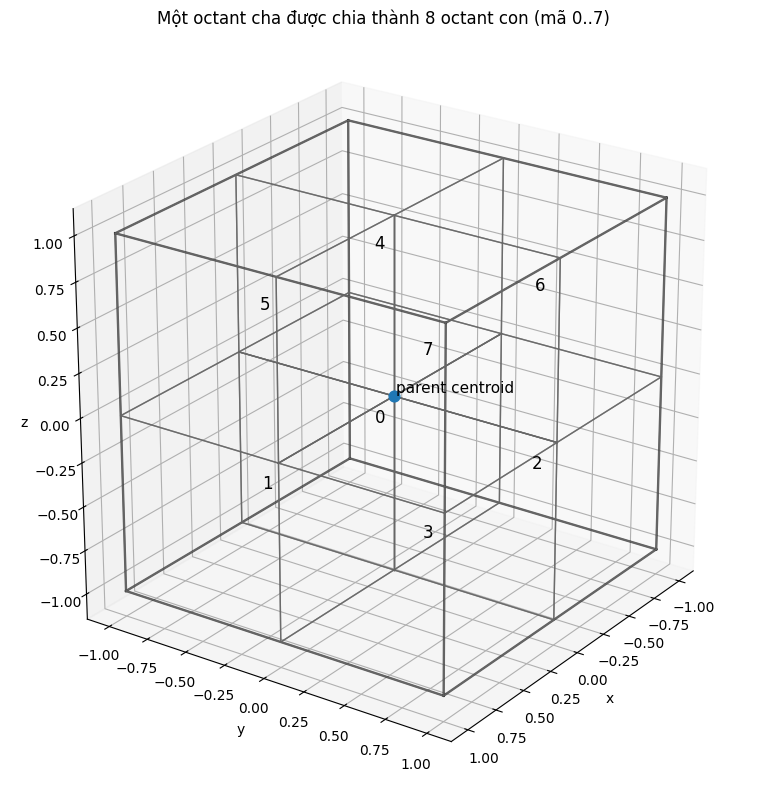

In [2]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def cube_edges(center, extent):
    c = np.asarray(center, dtype=float)
    e = float(extent)
    xs = [c[0]-e, c[0]+e]
    ys = [c[1]-e, c[1]+e]
    zs = [c[2]-e, c[2]+e]
    V = np.array([
        [xs[0], ys[0], zs[0]],
        [xs[1], ys[0], zs[0]],
        [xs[1], ys[1], zs[0]],
        [xs[0], ys[1], zs[0]],
        [xs[0], ys[0], zs[1]],
        [xs[1], ys[0], zs[1]],
        [xs[1], ys[1], zs[1]],
        [xs[0], ys[1], zs[1]],
    ])
    E = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    return V, E

def draw_cube(ax, center, extent, color="0.4", lw=1.0, alpha=1.0):
    V, E = cube_edges(center, extent)
    for i, j in E:
        ax.plot(*zip(V[i], V[j]), color=color, linewidth=lw, alpha=alpha)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

parent_center = np.array([0., 0., 0.])
parent_extent = 1.0
draw_cube(ax, parent_center, parent_extent, color="black", lw=1.7, alpha=0.6)

child_extent = 0.5 * parent_extent
offset = child_extent

for code in range(8):
    sx = 1 if (code & 1) else -1
    sy = 1 if (code & 2) else -1
    sz = 1 if (code & 4) else -1
    child_center = np.array([sx*offset, sy*offset, sz*offset])
    draw_cube(ax, child_center, child_extent, lw=1.0, alpha=0.8)
    ax.text(*(child_center + 0.08), f"{code}", fontsize=12)

ax.scatter([0], [0], [0], s=60)
ax.text(0.05, 0.05, 0.05, "parent centroid", fontsize=11)

ax.set_title("Một octant cha được chia thành 8 octant con (mã 0..7)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1,1,1))
ax.view_init(elev=24, azim=35)
plt.tight_layout()
plt.show()



## 4. `processPoints()` và `initialize()`: dựng cây ban đầu

Khi cây còn rỗng, `initialize(pts)` làm ba việc:

1. lọc bỏ điểm NaN bằng `processPoints()`,
2. tính bounding box \([min,max]\),
3. dựng một **root cube** bao toàn bộ point set rồi gọi `createOctant(...)`.

Công thức đúng với code là:

\[
\text{bbox\_center} = \frac{min+max}{2},
\qquad
\text{bbox\_halfsize} = \frac{max-min}{2}.
\]

Sau đó root được chọn là:

\[
c_{\text{root}} = min + \frac{max-min}{2},
\qquad
E_{\text{root}} = \max\!\left(\frac{max-min}{2}\right).
\]

Tức là root không phải hộp chữ nhật theo bbox, mà là **lập phương nhỏ nhất trục-song-song** đủ chứa bbox đó.

### Một chi tiết code rất dễ bỏ qua

Trong `processPoints()`, `n` được tăng trước rồi mới kiểm tra `if (n == 0)`.  
Vì `n` là `size_t`, nhánh đó về thực tế là **dead branch**. Kết quả vẫn đúng vì `min` và `max` đã được khởi tạo bằng các giá trị cực trị, nhưng đây là một chỗ implementation hơi “thừa” sau refactor.



## 5. `createOctant(...)`: chia đệ quy cho đến khi đủ nhỏ hoặc đủ thưa

Ý tưởng cốt lõi:

```cpp
if (points.size() > bucket_size_ && maxextent > 2*min_extent_) {
    // chia tiếp thành 8 child
} else {
    // trở thành leaf, giữ points ở đây
}
```

Điều này nói rằng một node sẽ **ngừng chia** nếu một trong hai điều kiện xảy ra:

- số điểm trong node đã không vượt quá `bucket_size_`,
- hoặc node đã đủ nhỏ theo ngưỡng `min_extent_`.

### Công thức child centroid

Nếu node cha có tâm \(c\) và extent \(E\), thì child extent là

\[
E_{\text{child}} = \frac{E}{2}.
\]

Và child centroid được đặt tại

\[
c_{\text{child}}
=
c + \frac{E}{2}
\begin{bmatrix}
s_x \\ s_y \\ s_z
\end{bmatrix},
\qquad s_x,s_y,s_z \in \{-1,+1\},
\]

đúng với dòng code:

```cpp
factor[] = {-0.5f, 0.5f};
child_centroid = centroid + factor[...] * maxextent;
```

### Tinh thần của hàm này

- **node trong** chỉ giữ con,
- **node lá** mới giữ điểm,
- mỗi lần chia là một lần “bucket points” được đẩy xuống 8 nhóm con theo `mortonCode`.

Nói đơn giản: `createOctant()` là hàm biến “một đống điểm trong một cube” thành “một subtree cân đối theo không gian”.



## 6. Lưu ý quan trọng về `extent` và `min_extent_`

Comment trong code nói rõ:

```cpp
float extent; // half of side-length
```

Nghĩa là nếu bạn thấy điều kiện

```cpp
maxextent > 2 * min_extent_
```

thì đừng đọc nó như “cạnh cell > 2 * min_extent”.

Đúng hơn, code đang nói:

\[
E > 2E_{\min},
\]

trong đó \(E\) là **half side-length**.  
Vì thế `min_extent_` trong header này hoạt động như một **ngưỡng scale nội bộ**, chứ không phải lúc nào cũng khớp 1-1 với trực giác “leaf edge length” mà người dùng thường nghĩ khi đọc tên config.

Đây là một trong những chỗ dễ gây tuning sai nếu bạn chỉ nhìn README mà không nhìn code.



## 7. `update(...)`: chèn điểm mới vào cây đang tồn tại

Đây là phần làm cho octree trở thành **incremental map** chứ không chỉ là cây tĩnh.

Ý tưởng của `update(pts)`:

1. nếu cây rỗng thì gọi `initialize(pts)`,
2. lọc NaN và tính `min, max` của batch mới,
3. nếu batch mới nằm ngoài root hiện tại thì **mở rộng root**,
4. sau đó gọi `updateOctant(root_, points)` để chèn vào subtree phù hợp.

### Vì sao phải mở rộng root?

Map là map tăng dần theo thời gian. Robot đi xa dần, nên scan mới có thể nằm ngoài cube gốc.

Code dùng lambda `expandTree(boundary)` để bọc root cũ trong một **parent lớn hơn** cho đến khi boundary nằm lọt trong parent đó.

Trực giác là:

- cây cũ không bị dựng lại từ đầu,
- ta chỉ “quấn” thêm một lớp cha bên ngoài,
- rồi để root cũ trở thành **một trong 8 con** của parent mới.

Đó là một cách rất rẻ để mở rộng không gian map.


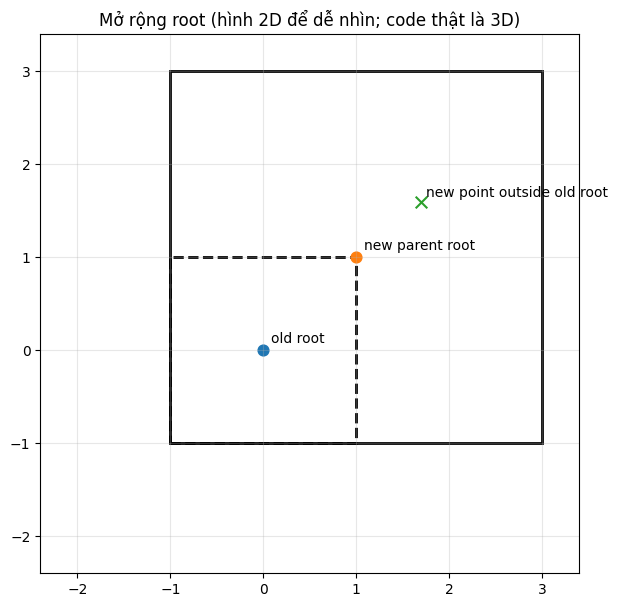

In [3]:

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7, 7))

# 2D analogy of 3D root expansion
old_center = np.array([0.0, 0.0])
old_extent = 1.0
new_center = np.array([1.0, 1.0])   # parent shifted toward outside point
new_extent = 2.0
outside_point = np.array([1.7, 1.6])

old_rect = Rectangle(old_center - old_extent, 2*old_extent, 2*old_extent,
                     fill=False, linewidth=2, linestyle='--')
new_rect = Rectangle(new_center - new_extent, 2*new_extent, 2*new_extent,
                     fill=False, linewidth=2)

ax.add_patch(new_rect)
ax.add_patch(old_rect)
ax.scatter(*old_center, s=60)
ax.scatter(*new_center, s=60)
ax.scatter(*outside_point, s=70, marker='x')

ax.text(*(old_center + 0.08), "old root")
ax.text(*(new_center + 0.08), "new parent root")
ax.text(*(outside_point + 0.05), "new point outside old root")

ax.set_title("Mở rộng root (hình 2D để dễ nhìn; code thật là 3D)")
ax.set_xlim(-2.4, 3.4)
ax.set_ylim(-2.4, 3.4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()



## 8. `updateOctant(...)`: chèn cục bộ thay vì dựng lại cả cây

Đây là hàm quyết định behavior khi thêm batch mới vào từng node.

Có hai trường hợp lớn:

### Trường hợp A: `octant` đang là leaf

Nếu leaf bị tràn:

```cpp
if (octant->points.size() + points.size() > bucket_size_
    and octant->extent > 2*min_extent_) {
    // gộp old + new rồi rebuild local subtree
}
```

Nghĩa là:

- lấy toàn bộ điểm cũ trong leaf,
- cộng với batch mới rơi vào leaf đó,
- rồi tạo lại **subtree cục bộ** từ chính leaf đó.

Cực kỳ quan trọng: đây **không phải dựng lại cả cây**, mà chỉ rebuild vùng nhỏ vừa bị tràn.

Nếu leaf không được chia tiếp nữa, code chỉ append điểm:

```cpp
octant->points.insert(...);
```

trừ khi nhánh downsample ở dưới chặn lại.

### Trường hợp B: `octant` là node trong

Khi đó batch mới được chia thành 8 nhóm con bằng `mortonCode(...)`, rồi:

- child nào chưa có thì tạo mới bằng `createOctant(...)`,
- child nào đã có thì gọi đệ quy `updateOctant(...)`.



## 9. Nhánh `downsample_`: nó đang downsample kiểu gì?

Chỗ này rất đáng chú ý:

```cpp
if (downsample_ and octant->extent <= 2*min_extent_
    and octant->points.size() > bucket_size_/8) {
  return;
}
```

Nó có nghĩa:

- nếu đã bật `downsample_`,
- và cell đã rất nhỏ,
- và leaf hiện tại đã có “đủ nhiều” điểm,

thì **bỏ qua toàn bộ batch mới** rơi vào leaf đó.

Đây không phải kiểu downsample “giữ điểm gần centroid voxel nhất” như một số cấu trúc voxel hoặc như mô tả so sánh với ikd-Tree trong paper.  
Ở implementation này, downsample là một kiểu **cap mật độ ở leaf nhỏ nhất**: nếu ô đã đủ đặc, thì thôi không nhét thêm nữa.

Nói dân dã:

> leaf quá nhỏ + đã đủ đông → ngừng nhồi thêm điểm.

Paper LIMOncello cũng nhấn mạnh implementation này đã được đơn giản hóa so với i-Octree gốc: không có tree rebalancing, không hỗ trợ box-wise deletion, và dùng một backend map gọn hơn để giữ real-time. *(nguồn: LIMOncello paper, mục III-E)*



## 10. `overlaps(...)`: kiểm tra sphere–AABB overlap để cắt tỉa

Đây là trái tim của cả `radiusSearch(...)` và `knn(...)`.

Ta có:

- query point \(q\),
- octant là một cube trục-song-song có tâm \(c\) và extent \(E\),
- bán kính tìm kiếm hiện tại \(r\).

Code tạo vector:

\[
d = |q-c| - E,
\]

theo từng trục.

Nếu viết bản toán học “sạch” hơn, khoảng cách từ điểm đến AABB là

\[
\Delta = \max(d, 0)
\]

theo từng thành phần, và octant overlap với sphere nếu

\[
\|\Delta\|^2 < r^2.
\]

Code trong file không viết nguyên xi công thức này mà dùng vài shortcut logic để reject sớm hoặc accept sớm.  
Nhưng ý nghĩa hình học là đúng một câu:

> **Nếu cube không thể cắt quả cầu tìm kiếm hiện tại, bỏ hẳn cả subtree của cube đó.**

Đó chính là pruning.


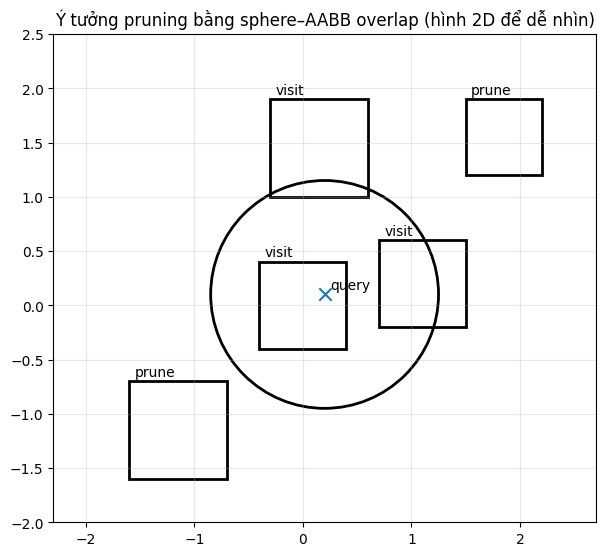

In [4]:

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

fig, ax = plt.subplots(figsize=(7, 7))

query = np.array([0.2, 0.1])
radius = 1.05

rects = [
    ((-1.6, -1.6), 0.9, "prune"),
    ((-0.4, -0.4), 0.8, "visit"),
    ((0.7, -0.2), 0.8, "visit"),
    ((1.5, 1.2), 0.7, "prune"),
    ((-0.3, 1.0), 0.9, "visit"),
]

for (xy, side, kind) in rects:
    x, y = xy
    color = {"visit": "tab:green", "prune": "tab:red"}[kind]
    rect = Rectangle((x, y), side, side, fill=False, linewidth=2, linestyle='-')
    ax.add_patch(rect)
    ax.text(x + 0.05, y + side + 0.05, kind, fontsize=10)

ax.add_patch(Circle(query, radius, fill=False, linewidth=2))
ax.scatter(*query, s=80, marker='x')
ax.text(*(query + 0.05), "query")

ax.set_title("Ý tưởng pruning bằng sphere–AABB overlap (hình 2D để dễ nhìn)")
ax.set_xlim(-2.3, 2.7)
ax.set_ylim(-2.0, 2.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()



## 11. `radiusSearch(...)`: khi nào được “ăn trọn cả subtree”?

Bản radius search của code có một optimization hay:

```cpp
if (3*octant->extent*octant->extent < sqr_radius and contains()) {
    get_points(octant, points);
    // duyệt hết subtree như một khối
}
```

Trong đó `contains()` kiểm tra corner xa nhất của cube đã nằm trong sphere hay chưa:

\[
\sum_j \left(|q_j-c_j| + E\right)^2 < r^2.
\]

Nếu đúng, thì **toàn bộ octant nằm gọn trong sphere**.  
Khi đó không cần đi đệ quy từng child nữa; ta lấy tất cả điểm của subtree luôn.

Trực giác:

- `overlaps(...)` trả lời câu hỏi “có cần đi xuống không?”
- `contains()` trả lời câu hỏi “có thể ăn cả nhánh một lần không?”

Đây là một kỹ thuật tối ưu cực quen thuộc trong tree search:  
**prune nếu chắc chắn vô ích, bulk-collect nếu chắc chắn mọi thứ đều hợp lệ.**



## 12. `knn(...)`: thuật toán k-láng giềng gần nhất của file này

Bản wrapper bên ngoài chỉ chuyển kiểu dữ liệu:

```cpp
Heap heap(k);
Point q(query.x, query.y, query.z);
knn(root_, q, heap);
```

Hàm đệ quy bên trong mới là phần quan trọng.

### Bước 1: đi trước vào child chứa query

```cpp
size_t morton = mortonCode(query, octant->centroid);
if (octant->child[morton] != nullptr) {
    if (knn(octant->child[morton], query, heap)) return true;
}
```

Tại sao?  
Vì child chứa query thường là nơi nhiều khả năng có hàng xóm gần nhất nhất.

### Bước 2: duyệt 7 sibling còn lại theo `ordered_indices`

Sau khi child chứa query được thăm trước, các sibling khác được thăm theo thứ tự heuristic đã bàn ở trên.

### Bước 3: dùng `heap.worstDist()` làm bán kính cắt tỉa

Ngay khi heap đã đầy, khoảng cách xa nhất trong top-k hiện tại trở thành:

\[
r_{\text{prune}}^2 = \text{heap.worstDist()}.
\]

Nếu một sibling octant còn không overlap với sphere bán kính đó, cả sibling subtree bị bỏ.

### Bước 4: `inside(radius)` cho phép kết thúc sớm

Nếu quả cầu bán kính `worstDist()` quanh query đã nằm trọn trong octant hiện tại, thì mọi điểm ở ngoài octant đều không thể tốt hơn top-k đang có. Khi đó hàm trả `true` để báo cho các mức trên rằng có thể dừng hẳn.

Đây là lý do `knn(...)` không chỉ là “đệ quy duyệt cây”, mà là một **branch-and-bound search** thực thụ.


In [5]:

# Minh họa rằng các sibling được thăm theo thứ tự "gần về nhị phân" trước.
summary_rows = []
for q in range(8):
    order = ordered_indices[q]
    summary_rows.append({
        "query child": q,
        "visit order": list(order),
        "Hamming ranks": [hamming(q, s) for s in order],
    })

pd.DataFrame(summary_rows)


,query child,visit order,Hamming ranks
0,0,"[1, 2, 4, 3, 5, 6, 7]","[1, 1, 1, 2, 2, 2, 3]"
1,1,"[0, 3, 5, 2, 4, 7, 6]","[1, 1, 1, 2, 2, 2, 3]"
2,2,"[0, 3, 6, 1, 4, 7, 5]","[1, 1, 1, 2, 2, 2, 3]"
3,3,"[1, 2, 7, 0, 5, 6, 4]","[1, 1, 1, 2, 2, 2, 3]"
4,4,"[0, 5, 6, 1, 2, 7, 3]","[1, 1, 1, 2, 2, 2, 3]"
5,5,"[1, 4, 7, 0, 3, 6, 2]","[1, 1, 1, 2, 2, 2, 3]"
6,6,"[2, 4, 7, 0, 3, 5, 1]","[1, 1, 1, 2, 2, 2, 3]"
7,7,"[3, 5, 6, 1, 2, 4, 0]","[1, 1, 1, 2, 2, 2, 3]"



## 13. Vì sao `Heap` đủ tốt dù không phải binary heap?

Nếu chỉ nhìn tên `Heap`, người mới hay tưởng đây phải là priority queue chuẩn.

Nhưng với bài toán của LIMOncello, `k` thường nhỏ vì mỗi point chỉ cần một số ít hàng xóm để fit local plane.  
Trong `State::update()`, số này lấy từ `cfg.ikfom.plane.points`, tức thường là một con số nhỏ như 5, 7, 10... chứ không phải vài nghìn. *(nguồn: State.hpp của LIMOncello)*

Với \(k\) nhỏ như vậy, một buffer cố định + insertion sort:

- rất đơn giản,
- rất cache-friendly,
- tránh overhead của cấu trúc phức tạp hơn.

Thế nên ở đây “đủ nhanh và gọn” quan trọng hơn việc dùng một binary heap textbook.

Một chi tiết implementation nho nhỏ: trong `Heap` có field `worst_distance_`, nhưng trong header hiện tại field này không được dùng. Đây có vẻ là dấu vết còn lại của một phiên bản cũ hơn.



## 14. Những chi tiết implementation dễ bỏ sót khi đọc file

### (a) `clear()` không reset `num_points_`

Header hiện tại có:

```cpp
void clear() {
  delete root_;
  root_ = nullptr;
}
```

nhưng không gán lại `num_points_ = 0`.

Vì vậy, nếu ai đó muốn **reuse** object sau `clear()` rồi lại `initialize()` hay `update()` tiếp, bộ đếm kích thước có thể giữ giá trị cũ.  
Trong luồng chạy bình thường của LIMOncello điều này có thể không lộ ra, nhưng đây là một chỗ nên để ý nếu bạn sửa code.

### (b) `Octant::is_active` không được dùng

Field này xuất hiện trong struct nhưng không tham gia logic tìm kiếm/chèn hiện tại. Khả năng cao đây là dấu vết còn lại từ bản i-Octree gốc hoặc từ một refactor.

### (c) Nhiều `std::move(...)` trong file thiên về ý đồ hơn là hiệu quả thực

Trong vài chỗ, điểm được push bằng `std::move(...)` dù source lại đang đi qua `const&`.  
Điều đó không làm hỏng logic, nhưng về mặt C++ thì không phải lúc nào cũng tạo ra move thực sự.



## 15. Liên hệ trực tiếp với `State::update()`

Trong `State.hpp`, mỗi điểm LiDAR sau khi được biến đổi lên world frame sẽ gọi:

```cpp
map.knn(query_point, k, neighbors, pointSearchSqDis);
```

Sau đó:

1. nếu không đủ `k` láng giềng thì bỏ,
2. nếu láng giềng xa nhất quá xa thì bỏ,
3. nếu `estimate_plane(...)` thất bại thì bỏ,
4. nếu hợp lệ thì dùng mặt phẳng đó tạo residual point-to-plane cho IESEKF. *(nguồn: State.hpp của LIMOncello)*

Do đó, chất lượng của `Octree.hpp` ảnh hưởng trực tiếp đến:

- **tốc độ** update,
- **tính ổn định** của plane fitting,
- và gián tiếp đến độ bền của odometry.

Paper LIMOncello cũng nói rõ rằng backend này là một **incremental i-Octree** được dùng để giữ real-time performance với memory growth ổn định, đồng thời đơn giản hóa so với các cấu trúc nặng hơn như ikd-Tree. *(nguồn: LIMOncello paper, mục III-E)*



## 16. So sánh nhanh giữa code này và mô tả trong paper

Paper mô tả i-Octree backend của LIMOncello theo các ý chính sau:

- mỗi node có tối đa 8 con,
- dùng Morton codes khi subdivide,
- subdivide đệ quy cho đến khi đủ ít điểm hoặc đủ nhỏ,
- không hỗ trợ box-wise deletion,
- không rebalance tree như bản i-Octree gốc,
- mục tiêu là giảm overhead và giữ real-time. *(nguồn: LIMOncello paper, mục III-E)*

Header hiện tại khớp với tinh thần đó:

- `Octant **child` đúng là cấu trúc 8 con,
- `mortonCode(...)` đúng là local Morton indexing,
- `update(...)` và `updateOctant(...)` cho incremental insertion,
- không có API xóa theo box,
- không có logic rebalance.

Một điểm nên hiểu kỹ: code vẫn có **local rebuild** khi một leaf bị tràn (`createOctant(...)` lại trên leaf đó).  
Tức là “đơn giản hóa” trong paper không có nghĩa là “không bao giờ chia lại leaf”, mà đúng hơn là **không giữ những cơ chế phức tạp hơn của original i-Octree / ikd-Tree**.



## 17. Tóm tắt bằng ngôn ngữ rất đời thường

Bạn có thể nhớ `Octree.hpp` theo 5 câu:

1. **Mỗi leaf giữ một túi điểm 3D.**
2. **Nếu túi quá đầy và ô còn đủ to, tách ô thành 8 ô con.**
3. **Nếu điểm mới nằm ngoài root, bọc cây cũ trong một root lớn hơn.**
4. **Khi tìm hàng xóm, đi vào vùng có khả năng gần nhất trước và cắt bỏ các vùng chắc chắn vô ích.**
5. **Kết quả k-NN được đưa cho `estimate_plane(...)`, rồi từ đó mới sinh residual để Kalman filter sửa pose.**

Nếu phải nén cả file vào một ý:

> `Octree.hpp` là bộ máy **tổ chức map 3D và trả hàng xóm cực nhanh**, để phần còn lại của LIMOncello có thể làm point-to-plane update theo thời gian thực.



## 18. Gợi ý đọc tiếp

Sau notebook này, thứ tự dễ hiểu nhất là:

1. `Plane.hpp` — vì đây là thứ nhận output của `map.knn(...)`,
2. `State.hpp` — để thấy các plane được biến thành residual và Jacobian ra sao,
3. rồi quay lại paper mục III-D / III-E để nối “code nhỏ” với “pipeline lớn”.

---

### Nguồn tham chiếu để làm notebook

- `include/Core/Octree.hpp` trong repo LIMOncello (implementation hiện tại).
- `include/Core/State.hpp` để thấy `map.knn(...)` được dùng ở đâu. *(nguồn: State.hpp của LIMOncello)*
- Paper **LIMOncello**, đặc biệt mục III-D và III-E về point-to-plane update và i-Octree backend. *(nguồn: LIMOncello paper, mục III-E)*
